## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [93]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [94]:
from google.colab import files
uploaded = files.upload()

Saving shopping_trends.csv to shopping_trends (1).csv


In [95]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df = pd.read_csv('shopping_trends.csv')

In [96]:
# TODO: check the dataset size with df.shape
df.shape

(3900, 19)

In [97]:
# TODO: drop the Customer ID column
df_clean = df.drop(columns='Customer ID')
df_clean

,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [98]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       3900 non-null   int64  
 1   Gender                    3900 non-null   object 
 2   Item Purchased            3900 non-null   object 
 3   Category                  3900 non-null   object 
 4   Purchase Amount (USD)     3900 non-null   int64  
 5   Location                  3900 non-null   object 
 6   Size                      3900 non-null   object 
 7   Color                     3900 non-null   object 
 8   Season                    3900 non-null   object 
 9   Review Rating             3900 non-null   float64
 10  Subscription Status       3900 non-null   object 
 11  Payment Method            3900 non-null   object 
 12  Shipping Type             3900 non-null   object 
 13  Discount Applied          3900 non-null   object 
 14  Promo Co

In [99]:
# TODO: check missing values with df.isnull().sum()
df_clean.isnull().sum()

,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0
Review Rating,0


In [100]:
# TODO: check duplicate rows with df.duplicated().sum()
df_clean.duplicated().sum()

np.int64(0)

In [101]:
# TODO: univariate — describe numeric columns
df_clean.describe()

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,25.351538
std,15.207589,23.685392,0.716223,14.447125
min,18.000000,20.000000,2.500000,1.000000
25%,31.000000,39.000000,3.100000,13.000000
50%,44.000000,60.000000,3.700000,25.000000
75%,57.000000,81.000000,4.400000,38.000000
max,70.000000,100.000000,5.000000,50.000000


In [102]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']

## **EDA**

### **Item Purchased**

In [103]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
top_items_male = male_df['Item Purchased'].value_counts().reset_index(name='count')
top_items_female = female_df['Item Purchased'].value_counts().reset_index(name='count')
top_items_all_customers = df['Item Purchased'].value_counts().reset_index(name='count')

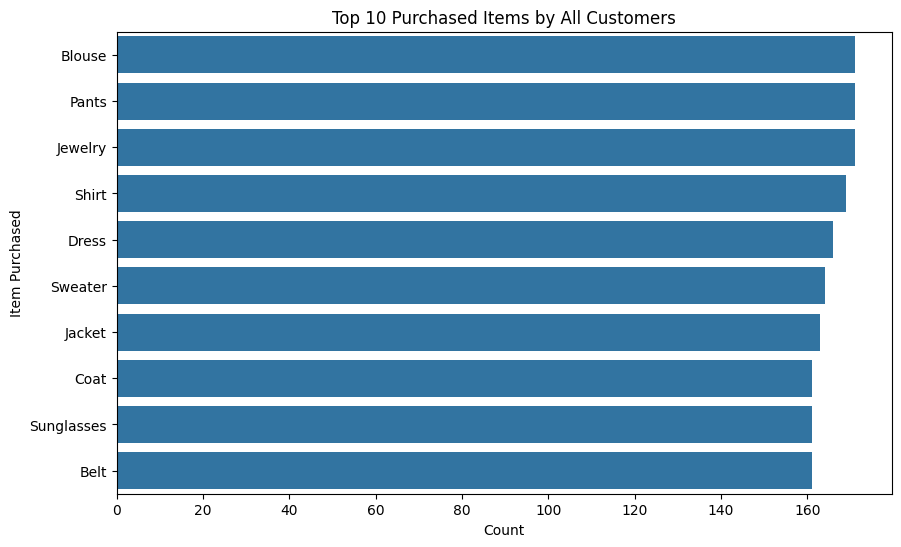

In [104]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data = top_items_all_customers.head(10),
    x='count',
    y='Item Purchased'
)
plt.title("Top 10 Purchased Items by All Customers")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

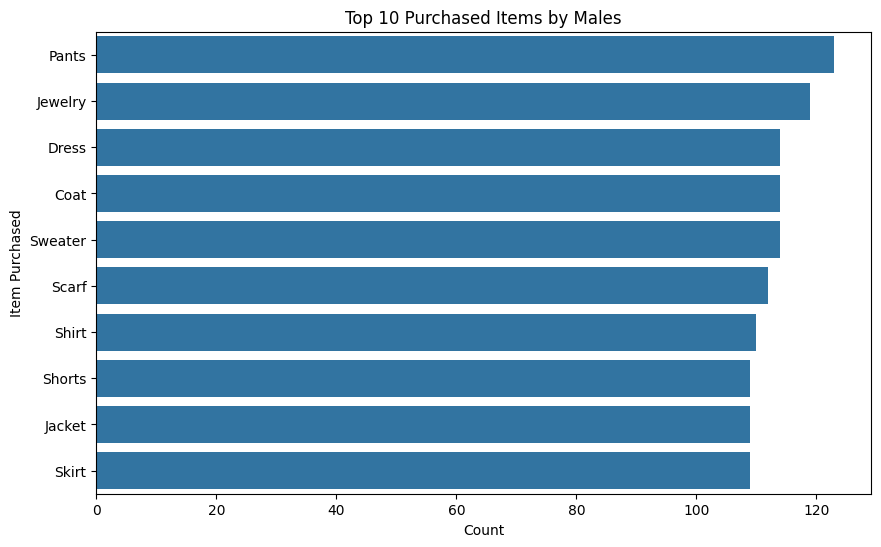

In [105]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_items_male.head(10),
    x='count',
    y='Item Purchased'
)
plt.title("Top 10 Purchased Items by Males")
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

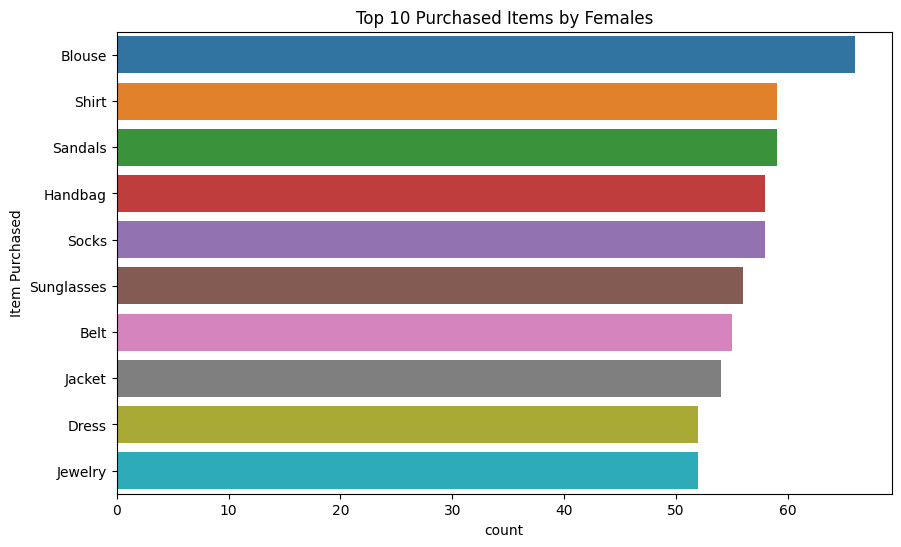

In [106]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
plt.figure(figsize=(10, 6))
sns.barplot(
    data= top_items_female.head(10),
    y='Item Purchased',
    x='count',
    hue='Item Purchased',
    dodge=False,
    legend=False
)
plt.title("Top 10 Purchased Items by Females")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [131]:
# TODO: count Size with value_counts() for all customers
df_clean['Size'].value_counts()

,count
Size,
M,1755
L,1053
S,663
XL,429


In [132]:
# TODO: count Size with value_counts() for male_df and female_df
size_male_df = male_df['Size'].value_counts()
size_female_df = female_df['Size'].value_counts()
print("size of male_df:")
print(size_male_df)
print("size of female_df:")
print(size_female_df)

size of male_df:
Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
size of female_df:
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [109]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg =df['Category'].value_counts().reset_index(name="count")

In [110]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df
ctg_male = male_df['Category'].value_counts().reset_index()
ctg_female = female_df['Category'].value_counts().reset_index()
print("cout category for male_df:")
print(ctg_male)
print("cout category for female_df:")
print(ctg_female)


cout category for male_df:
      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
cout category for female_df:
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


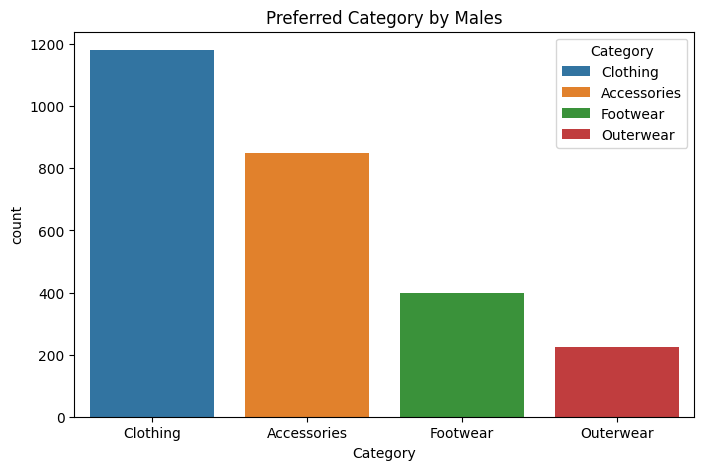

In [111]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg_male,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=True
)
plt.title("Preferred Category by Males")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

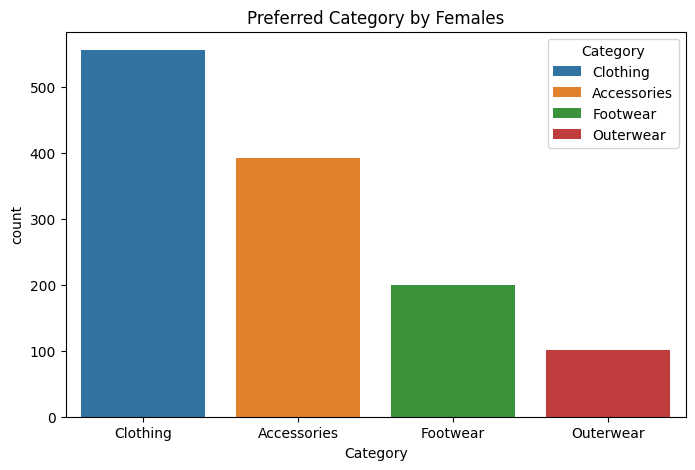

In [112]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
   data=ctg_female,
   x='Category',
   y='count',
   hue='Category',
   dodge=False,
   legend=True
)
plt.title("Preferred Category by Females")
plt.xlabel('Category')
plt.ylabel('count')
plt.show()

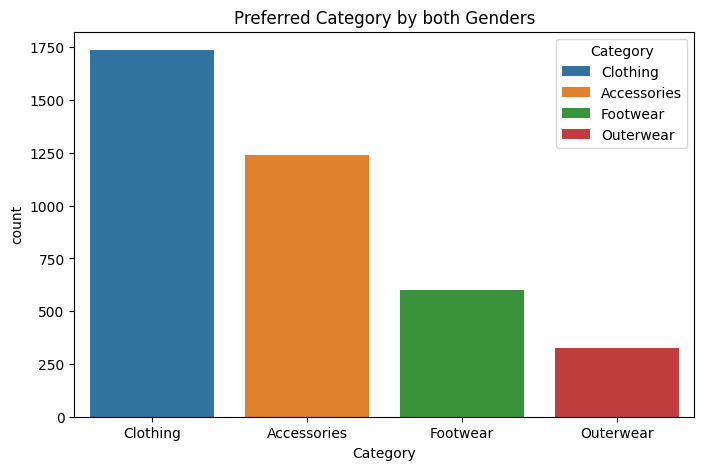

In [113]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ctg,
    x='Category',
    y='count',
    hue='Category',
    dodge=False,
    legend=True
)
plt.title("Preferred Category by both Genders")
plt.show()



In [133]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
waffle_data_m = dict(male_df['Category'].value_counts())
waffle_data_f = dict(female_df['Category'].value_counts())

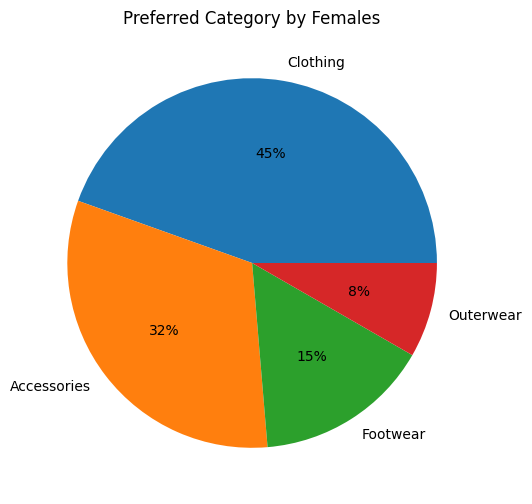

In [115]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    x = waffle_data_f.values(),
    labels = waffle_data_f.keys(),
    autopct='%.0f%%'

)
plt.title("Preferred Category by Females")
plt.show()

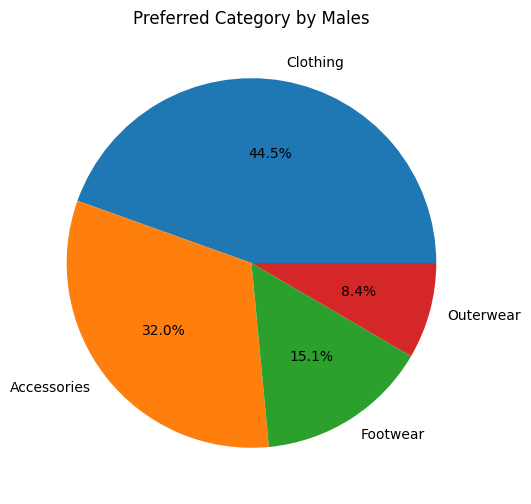

In [116]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
plt.figure(figsize=(6, 6))
plt.pie(
    waffle_data_m.values(),
    labels=waffle_data_m.keys(),
    autopct='%1.1f%%'
)
plt.title("Preferred Category by Males")
plt.show()

### **Review ratings**

In [117]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f =
# avg_cr_f = ?
cr_f = female_df[female_df['Category'] == 'Clothing']
avg_cr_f = cr_f['Review Rating'].mean()


In [118]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?
cr_m = male_df[male_df['Category'] == 'Clothing']
avg_cr_m = cr_m['Review Rating'].mean()


In [119]:
# avg_cr_m,avg_cr_f
print("mean of review ratting for female: ", avg_cr_f.round(4))
print('mean of Review Rating for male: ', avg_cr_m.round(4))

mean of review ratting for female:  3.7045
mean of Review Rating for male:  3.7319


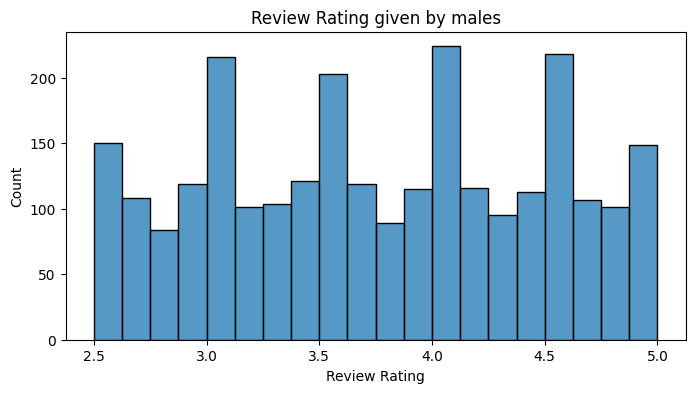

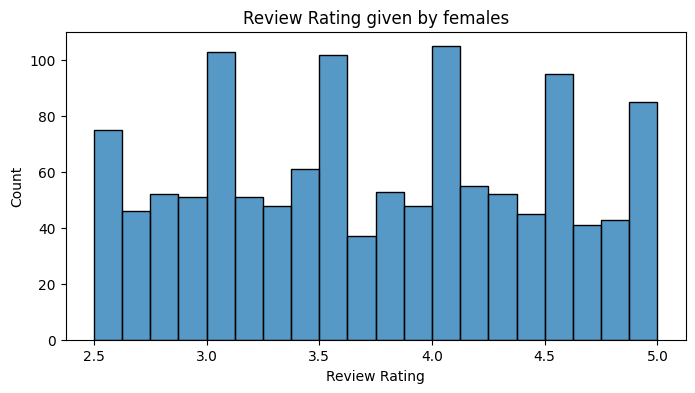

In [120]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
# ?
plt.figure(figsize=(8, 4))
sns.histplot(data=female_df, x='Review Rating', bins=20)
plt.title("Review Rating given by females")
plt.show()

In [121]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)
cr_m['Review Rating'].value_counts()


,count
Review Rating,
3.7,61
3.4,59
2.7,55
2.9,55
4.2,52
3.9,52
4.0,52
3.0,49
3.3,49


### **Purchase Amount (USD)**

In [122]:
# TODO: sum Purchase Amount (USD) for males
m_tpa = male_df['Purchase Amount (USD)'].sum()
print(f"Total of Purchase Amount (USD) for males: {m_tpa}")

# # TODO: sum Purchase Amount (USD) for females
f_tpa = female_df['Purchase Amount (USD)'].sum()
print(f"Total of Purchase Amount (USD) for females: {f_tpa}")

Total of Purchase Amount (USD) for males: 157890
Total of Purchase Amount (USD) for females: 75191


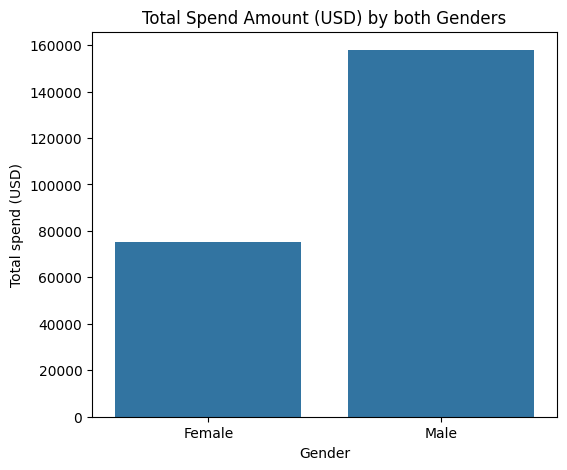

In [123]:
# TODO: plot total spend by gender with sns.barplot()
spend_by_gender = df.groupby('Gender')['Purchase Amount (USD)'].sum()
plt.figure(figsize=(6, 5))
sns.barplot(
    spend_by_gender
)
plt.title("Total Spend Amount (USD) by both Genders")
plt.ylabel('Total spend (USD)')
plt.show()

In [124]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_f = cr_f
ca_f = female_df[female_df['Category']=='Accessories']
cf_f = female_df[female_df['Category'] == 'Footwear']
co_f = female_df[female_df['Category'] == 'Outerwear']

In [134]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
cc_m = cr_m
ca_m = male_df[male_df['Category'] == 'Accessories']
cf_m = male_df[male_df['Category'] == 'Footwear']
co_m = male_df[male_df['Category'] == 'Outerwear']

In [126]:
# TODO: create pcu dict from Promo Code Used value_counts()
pcu = dict(df['Promo Code Used'].value_counts())
pcu

{'No': np.int64(2223), 'Yes': np.int64(1677)}

### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

<Axes: >

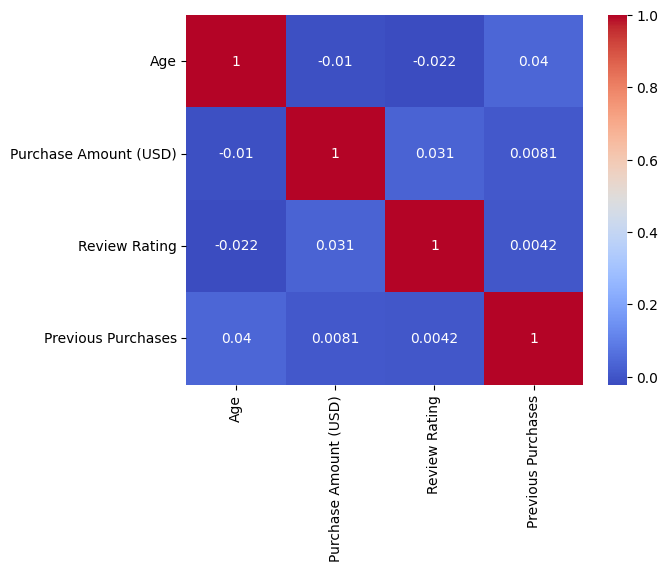

In [127]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()
selected_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
corr_selected_cols = df[selected_cols].corr()
sns.heatmap(corr_selected_cols, annot=True, cmap="coolwarm")

### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [136]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
df_processed = pd.get_dummies(df_clean, columns=['Gender', 'Size', 'Category'], dtype=float)
df_processed.head()

,Age,Item Purchased,Purchase Amount (USD),Location,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,...,Gender_Female,Gender_Male,Size_L,Size_M,Size_S,Size_XL,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear
0,55,Blouse,53,Kentucky,Gray,Winter,3.1,Yes,Credit Card,Express,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,19,Sweater,64,Maine,Maroon,Winter,3.1,Yes,Bank Transfer,Express,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,50,Jeans,73,Massachusetts,Maroon,Spring,3.1,Yes,Cash,Free Shipping,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,21,Sandals,90,Rhode Island,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,45,Blouse,49,Oregon,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [137]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()

df_processed['Amount_minmax'] = minmax_scaler.fit_transform(df_processed[['Purchase Amount (USD)']])
df_processed['Age_standard'] = standard_scaler.fit_transform(df_processed[['Age']])
df_processed[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

,Purchase Amount (USD),Amount_minmax,Age,Age_standard
0,53,0.4125,55,0.718913
1,64,0.5500,19,-1.648629
2,73,0.6625,50,0.390088
3,90,0.8750,21,-1.517099
4,49,0.3625,45,0.061263


In [138]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
bins = [df_processed['Purchase Amount (USD)'].min(),
        df_processed['Purchase Amount (USD)'].quantile(0.33),
        df_processed['Purchase Amount (USD)'].quantile(0.66),
        df_processed['Purchase Amount (USD)'].max()]
labels = ['Low', 'Medium', 'High']
df_processed['Amount_bin'] = pd.cut(df_processed['Purchase Amount (USD)'], bins=bins, labels=labels, include_lowest=True)
df_processed['Amount_bin'].value_counts()

,count
Amount_bin,
Medium,1303
Low,1300
High,1297


### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
-   Khách hàng nam mua hàng nhiều hơn đáng kể so với khách hàng nữ về số lượng sản phẩm.
-   Các danh mục "Clothing" và "Accessories" là những danh mục phổ biến nhất đối với cả nam và nữ.
-   Điểm đánh giá trung bình không có sự khác biệt lớn giữa nam và nữ.
-   Mặt hàng "Blouse" và "Pants" là những mặt hàng được mua nhiều nhất nói chung.  
-   Việc sử dụng mã khuyến mãi là khá phổ biến, với 1677 giao dịch sử dụng mã khuyến mãi so với 2223 không sử dụng.

Caveat: correlation is not causation.